In [7]:
import mysql.connector

# Connect to MySQL
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='root',
    database='UsedCarsDB'
)
cursor = conn.cursor()

# 1. Average price of used cars by brand, model, and year
def avg_price_by_brand_model_year():
    print("\n--- Average Price by Brand, Model, and Year ---")
    query = """
    SELECT 
        SUBSTRING_INDEX(name, ' ', 1) AS brand,
        name AS model,
        year,
        ROUND(AVG(price), 0) AS avg_price
    FROM used_cars
    GROUP BY brand, model, year
    ORDER BY avg_price DESC
    LIMIT 10;
    """
    cursor.execute(query)
    for row in cursor.fetchall():
        print(f"{row[0]} | {row[1]} | {row[2]} ➜ ₹{row[3]:,.0f}")

# 2. Most common car makes and models
def most_common_makes_models():
    print("\n--- Most Common Car Makes and Models ---")
    query = """
    SELECT name, COUNT(*) AS count
    FROM used_cars
    GROUP BY name
    ORDER BY count DESC
    LIMIT 10;
    """
    cursor.execute(query)
    for name, count in cursor.fetchall():
        print(f"{name}: {count} listings")

# 3. Price trends based on mileage and year
def price_trends_mileage_year():
    print("\n--- Price Trends Based on Mileage and Year ---")
    query = """
    SELECT year, ROUND(AVG(price), 0) AS avg_price, ROUND(AVG(mileage), 0) AS avg_mileage
    FROM used_cars
    GROUP BY year
    ORDER BY year ASC;
    """
    cursor.execute(query)
    for row in cursor.fetchall():
        print(f"Year {row[0]} ➜ Avg Price: ₹{row[1]:,.0f}, Avg Mileage: {row[2]:,} km")

# 4. Distribution of transmission types and fuel types
def distribution_transmission_fuel():
    print("\n--- Transmission Types Distribution ---")
    cursor.execute("SELECT transmission, COUNT(*) FROM used_cars GROUP BY transmission;")
    for transmission, count in cursor.fetchall():
        print(f"{transmission}: {count}")

    print("\n--- Fuel Types Distribution ---")
    cursor.execute("SELECT fuel, COUNT(*) FROM used_cars GROUP BY fuel;")
    for fuel, count in cursor.fetchall():
        print(f"{fuel}: {count}")

# 5. Best value cars based on price-to-mileage ratio
def best_value_cars():
    print("\n--- Best Value Cars (Based on Price-to-Mileage Ratio) ---")
    query = """
    SELECT name, year, price, mileage, ROUND(price / mileage, 2) AS ratio
    FROM used_cars
    WHERE mileage > 0
    ORDER BY ratio asc
    LIMIT 10;
    """
    cursor.execute(query)
    for row in cursor.fetchall():
        print(f"{row[0]} ({row[1]}) ➜ ₹{row[2]:,.0f}, {row[3]:,} km ➜ Ratio: {row[4]}")

# Simple CLI menu
def analytical_menu():
    while True:
        print("\n====== Analytical Computation Menu ======")
        print("1. Average Price by Brand, Model, and Year")
        print("2. Most Common Car Makes and Models")
        print("3. Price Trends (Mileage & Year)")
        print("4. Transmission and Fuel Type Distribution")
        print("5. Best Value Cars (Price-to-Mileage Ratio)")
        print("6. Exit")

        choice = input("Choose an option (1-6): ")

        if choice == '1':
            avg_price_by_brand_model_year()
        elif choice == '2':
            most_common_makes_models()
        elif choice == '3':
            price_trends_mileage_year()
        elif choice == '4':
            distribution_transmission_fuel()
        elif choice == '5':
            best_value_cars()
        elif choice == '6':
            print("Exiting Analytical Menu.")
            break
        else:
            print("Invalid choice. Please try again.")

# Run the menu
analytical_menu()

# Close MySQL connection
cursor.close()
conn.close()



====== Analytical Computation Menu ======
1. Average Price by Brand, Model, and Year
2. Most Common Car Makes and Models
3. Price Trends (Mileage & Year)
4. Transmission and Fuel Type Distribution
5. Best Value Cars (Price-to-Mileage Ratio)
6. Exit



--- Best Value Cars (Based on Price-to-Mileage Ratio) ---
Tata (2010) ➜ ₹45,000, 26.0 km ➜ Ratio: 1730.77
Tata (2011) ➜ ₹45,000, 26.0 km ➜ Ratio: 1730.77
Maruti (2001) ➜ ₹30,000, 17.3 km ➜ Ratio: 1734.1
Maruti (2004) ➜ ₹33,351, 18.9 km ➜ Ratio: 1764.6
Tata (2011) ➜ ₹46,000, 26.0 km ➜ Ratio: 1769.23
Tata (2012) ➜ ₹45,000, 25.4 km ➜ Ratio: 1771.65
Maruti (1997) ➜ ₹29,999, 16.1 km ➜ Ratio: 1863.29
Maruti (2000) ➜ ₹31,000, 16.1 km ➜ Ratio: 1925.47
Maruti (2004) ➜ ₹31,504, 16.1 km ➜ Ratio: 1956.77
Tata (2010) ➜ ₹55,000, 26.0 km ➜ Ratio: 2115.38

====== Analytical Computation Menu ======
1. Average Price by Brand, Model, and Year
2. Most Common Car Makes and Models
3. Price Trends (Mileage & Year)
4. Transmission and Fuel Type Distribution
5. Best Value Cars (Price-to-Mileage Ratio)
6. Exit
Exiting Analytical Menu.



========== Used Car Insights Menu ==========
1. Summary Statistics and Key Metrics
2. Top 10 Most Listed Car Models
3. Cars Offering the Best Resale Value
4. Market Trends (Price vs Year and Mileage)
5. Buyer Preferences (Transmission/Fuel)
6. Exit



--- Summary Statistics ---
              price     km_driven
count  7.889000e+03  7.889000e+03
mean   6.496753e+05  6.919859e+04
std    8.134766e+05  5.682769e+04
min    2.999900e+04  1.000000e+00
25%    2.700000e+05  3.500000e+04
50%    4.500000e+05  6.000000e+04
75%    6.900000e+05  9.550000e+04
max    1.000000e+07  2.360457e+06

--- Mode Statistics ---
sales_id                               1
name                              Maruti
year                              2017.0
price                           300000.0
km_driven                       120000.0
region                           Central
state_or_province             California
city                       New York City
fuel                              Diesel
seller_type                   Individual
transmission                      Manual
owner                        First_Owner
mileage                             18.9
engine                            1248.0
max_power                           74.0
torque                    

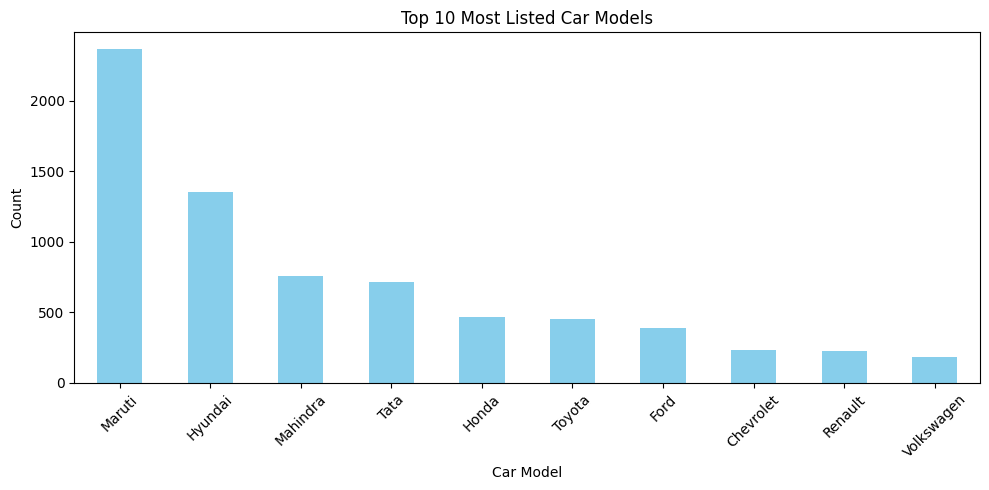


========== Used Car Insights Menu ==========
1. Summary Statistics and Key Metrics
2. Top 10 Most Listed Car Models
3. Cars Offering the Best Resale Value
4. Market Trends (Price vs Year and Mileage)
5. Buyer Preferences (Transmission/Fuel)
6. Exit

--- Top 10 Cars with Best Resale Value ---
         name  year   price  km_driven  price_to_mileage_ratio
6580     Tata  2004   50000     271000                0.184502
3370  Hyundai  2007  550000    2360457                0.233006
7137     Ford  2006   55000     201000                0.273632
5511   Maruti  2000   50000     180000                0.277778
1867   Maruti  2004   31504     110000                0.286400
2665   Maruti  2004   70000     220000                0.318182
4565     Tata  2004   80000     248200                0.322321
7459   Maruti  2006   65000     198000                0.328283
3906   Daewoo  2001   45000     137000                0.328467
2517   Maruti  2003   55000     167000                0.329341


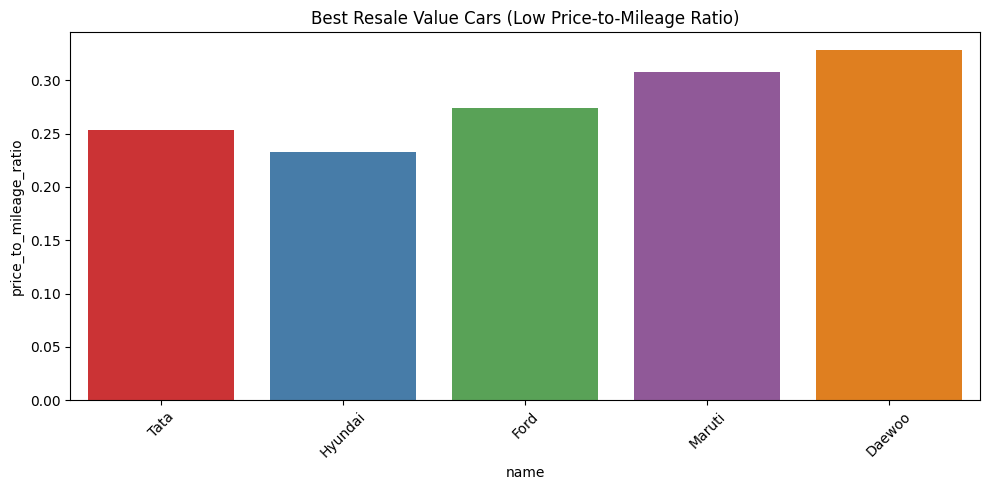


========== Used Car Insights Menu ==========
1. Summary Statistics and Key Metrics
2. Top 10 Most Listed Car Models
3. Cars Offering the Best Resale Value
4. Market Trends (Price vs Year and Mileage)
5. Buyer Preferences (Transmission/Fuel)
6. Exit

--- Market Trends ---


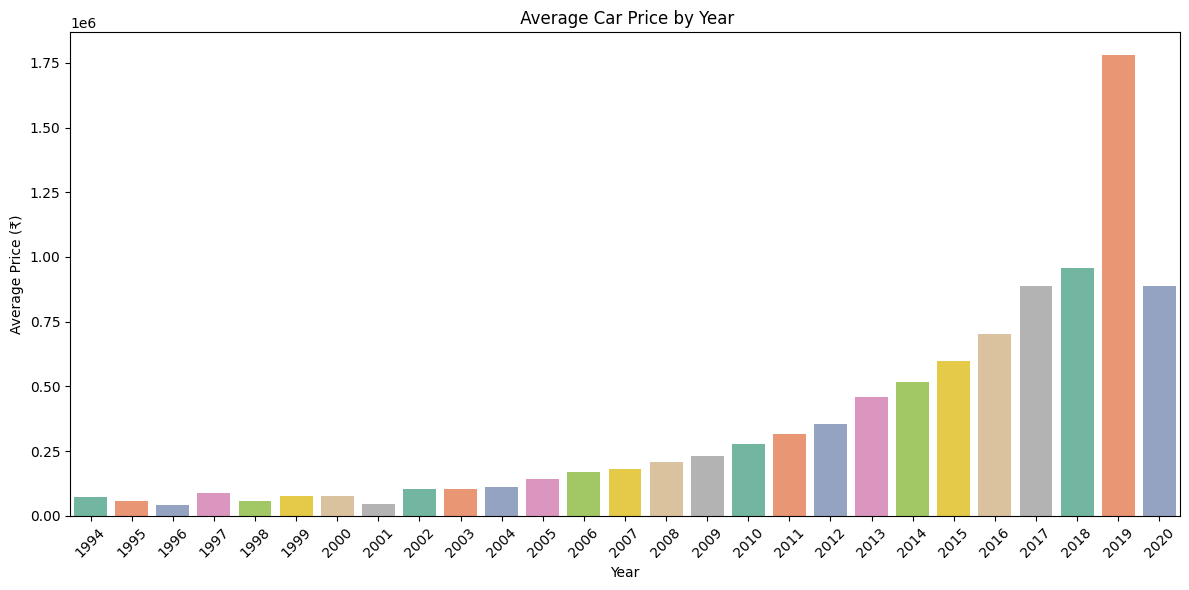

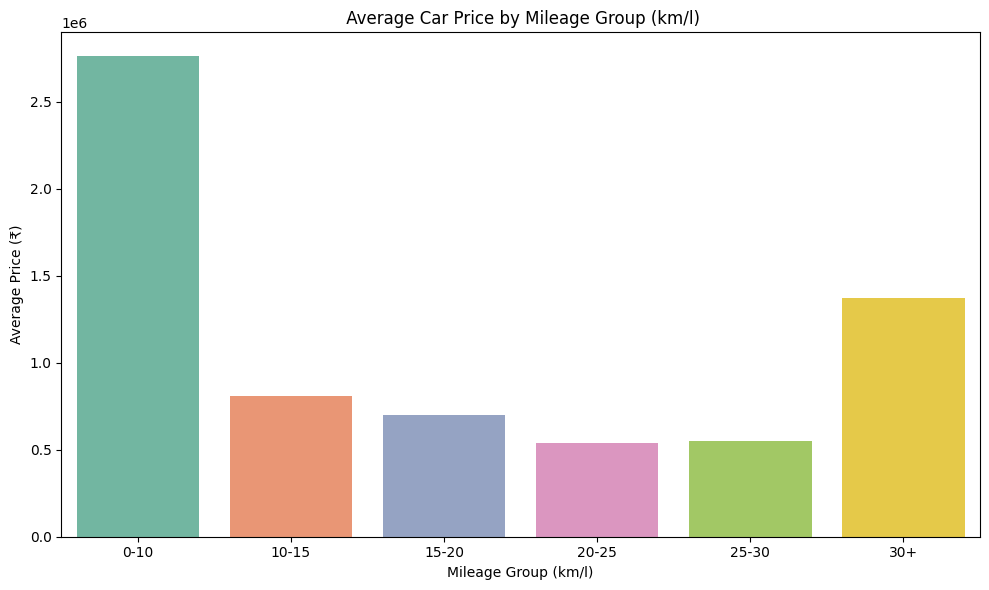


========== Used Car Insights Menu ==========
1. Summary Statistics and Key Metrics
2. Top 10 Most Listed Car Models
3. Cars Offering the Best Resale Value
4. Market Trends (Price vs Year and Mileage)
5. Buyer Preferences (Transmission/Fuel)
6. Exit

--- Transmission Type Distribution ---


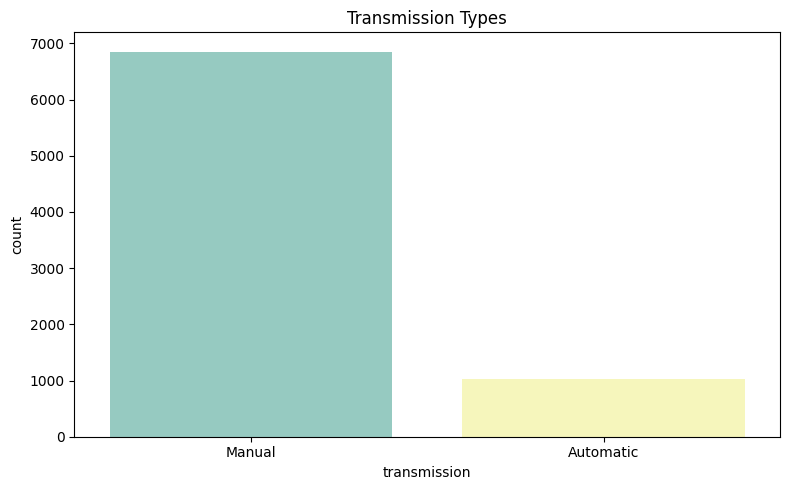


--- Fuel Type Distribution ---


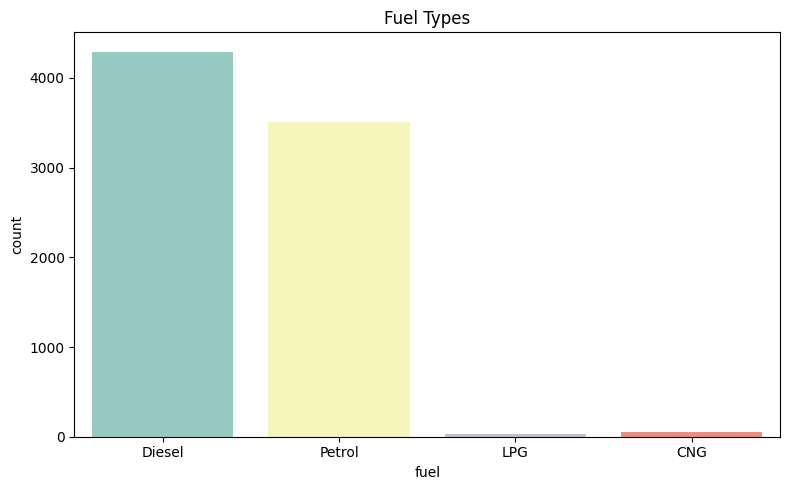


========== Used Car Insights Menu ==========
1. Summary Statistics and Key Metrics
2. Top 10 Most Listed Car Models
3. Cars Offering the Best Resale Value
4. Market Trends (Price vs Year and Mileage)
5. Buyer Preferences (Transmission/Fuel)
6. Exit
Exiting... Thank you!


In [13]:

from cleanData import load_cleaned_data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=load_cleaned_data()

# Calculate price_to_mileage_ratio
df['price_to_mileage_ratio'] = df['price'] / df['km_driven']

def summary_stats():
    print("\n--- Summary Statistics ---")
    print(df[['price', 'km_driven']].describe())

    print("\n--- Mode Statistics ---")
    print(df.mode().iloc[0])

def top_models():
    print("\n--- Top 10 Most Listed Car Models ---")
    top_10 = df['name'].value_counts().head(10)
    print(top_10)

    # Bar Chart
    top_10.plot(kind='bar', figsize=(10, 5), color='skyblue')
    plt.title('Top 10 Most Listed Car Models')
    plt.ylabel('Count')
    plt.xlabel('Car Model')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def best_resale_value():
    print("\n--- Top 10 Cars with Best Resale Value ---")
    top_resale = df[['name', 'year', 'price', 'km_driven', 'price_to_mileage_ratio']] \
        .sort_values(by='price_to_mileage_ratio') \
        .head(10)
    print(top_resale)

    # Bar chart of resale value
    plt.figure(figsize=(10, 5))
    sns.barplot(
        x='name',
        y='price_to_mileage_ratio',
        hue='name',
        data=top_resale,
        #palette='viridis',
        palette='Set1',
        legend=False,
        errorbar=None
    )
    plt.title('Best Resale Value Cars (Low Price-to-Mileage Ratio)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def market_trends():
    print("\n--- Market Trends ---")

    # Average Car Price by Year
    avg_price_by_year = df.groupby('year')['price'].mean().reset_index()

    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=avg_price_by_year, 
        x='year',
        y='price',
        hue='year',
        #palette='Blues_d',
        palette='Set2',
        legend=False,
        errorbar=None
    )
    plt.title(' Average Car Price by Year')
    plt.xlabel('Year')
    plt.ylabel('Average Price (₹)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Average Price by Mileage Buckets
    mileage_bins = pd.cut(df['mileage'], bins=[0, 10, 15, 20, 25, 30, 50], labels=['0-10', '10-15', '15-20', '20-25', '25-30', '30+'])
    df['mileage_group'] = mileage_bins
    #avg_price_by_mileage = df.groupby('mileage_group')['price'].mean().reset_index()
    avg_price_by_mileage = df.groupby('mileage_group', observed=True)['price'].mean().reset_index()

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=avg_price_by_mileage,
        x='mileage_group',
        y='price',
        hue='mileage_group',
        palette='Set2',
        legend=False,
        errorbar=None
    )
    plt.title(' Average Car Price by Mileage Group (km/l)')
    plt.xlabel('Mileage Group (km/l)')
    plt.ylabel('Average Price (₹)')
    plt.tight_layout()
    plt.show()



def buyer_preferences():
    print("\n--- Transmission Type Distribution ---")
    plt.figure(figsize=(8, 5))
    sns.countplot(
        x='transmission',
        hue='transmission',
        data=df, 
        palette='Set3')
    plt.title("Transmission Types")
    plt.tight_layout()
    plt.show()

    print("\n--- Fuel Type Distribution ---")
    plt.figure(figsize=(8, 5))
    sns.countplot(
        x='fuel',
        hue='fuel',
        data=df, 
        palette='Set3')
    plt.title("Fuel Types")
    plt.tight_layout()
    plt.show()

def main_menu():
    while True:
        print("\n========== Used Car Insights Menu ==========")
        print("1. Summary Statistics and Key Metrics")
        print("2. Top 10 Most Listed Car Models")
        print("3. Cars Offering the Best Resale Value")
        print("4. Market Trends (Price vs Year and Mileage)")
        print("5. Buyer Preferences (Transmission/Fuel)")
        print("6. Exit")

        choice = input("Enter your choice (1-6): ")

        if choice == '1':
            summary_stats()
        elif choice == '2':
            top_models()
        elif choice == '3':
            best_resale_value()
        elif choice == '4':
            market_trends()
        elif choice == '5':
            buyer_preferences()
        elif choice == '6':
            print("Exiting... Thank you!")
            break
        else:
            print("Invalid input. Please enter a number from 1 to 6.")

# Run the interactive menu
main_menu()
